# FrozenLake Monte Carlo & TD Control

Этот ноутбук повторяет реализацию из `08_mc_vs_td/mc_td_algorithm.py` и демонстрирует
сравнение прогнозирования ценности состояний методами Monte Carlo и Temporal Difference (TD).


## Описание задачи FrozenLake

`FrozenLake-v1` описывает поле 4×4, где агент стартует в верхнем левом углу и
пытается добраться до клетки с сокровищем в нижнем правом углу, избегая прорубей.
Состояние кодируется индексом клетки, действия — четыре направления движения.
Награда равна 1 при достижении цели, иначе 0; эпизод обрывается при падении в
прорубь, достижении цели или превышении лимита шагов.


## Ключевые формулы

**Monte Carlo (первое посещение):**
$$
V(s) \leftarrow V(s) + \alpha \left( G_t - V(s) \right), \quad
G_t = \sum_{k=0}^{T-t-1} \gamma^k r_{t+k+1}
$$
 
**TD(0):**
$$
V(s) \leftarrow V(s) + \alpha \left( r_{t+1} + \gamma V(s') - V(s) \right)
$$
 
TD использует бутстрэппинг (опирается на текущие оценки), тогда как MC — на
фактический возврат эпизода.

In [1]:
!pip install -U pip
!pip install "gymnasium[classic-control]" "matplotlib" -q

In [17]:
import numpy as np
import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from typing import Callable, DefaultDict, Dict, Iterable, List, Optional, Tuple

from PIL import Image, ImageDraw, ImageFont


Policy = Callable[[int], np.ndarray]

## Вспомогательные функции


In [18]:
def set_seeds(env: gym.Env, seed: int) -> None:
    """Seed numpy and, when supported, the Gym environment RNGs.

    Args:
        env: Environment whose internal random number generators should be
            reset.
        seed: Deterministic seed forwarded to numpy and the environment.

    Notes:
        Older Gym releases may not implement ``reset(seed=...)``; in that case
        the call is silently ignored.
    """

    np.random.seed(seed)
    try:
        env.reset(seed=seed)
        if hasattr(env.action_space, "seed"):
            env.action_space.seed(seed)
        if hasattr(env.observation_space, "seed"):
            env.observation_space.seed(seed)
    except TypeError:
        # Legacy Gym versions may not accept reset(seed=...). Ignored.
        pass


def reset(env: gym.Env) -> int:
    """Reset the environment and return the initial state index.

    Args:
        env: Environment to reset.

    Returns:
        Integer representing the initial discrete state.
    """

    obs, _ = env.reset()
    return int(obs)


def step(env: gym.Env, action: int) -> Tuple[int, float, bool, Dict[str, np.ndarray]]:
    """Execute one environment step using the Gym v0.26+ API.

    Args:
        env: Environment to interact with.
        action: Discrete action sampled from the policy.

    Returns:
        Tuple containing the next state index, scalar reward, boolean episode
        termination flag, and the info dict provided by Gym.
    """

    obs, reward, terminated, truncated, info = env.step(action)
    done = bool(terminated or truncated)
    return int(obs), float(reward), done, info


def moving_average(series: Iterable[float], window: int = 100) -> np.ndarray:
    """Compute a simple moving average over the supplied sequence.

    Args:
        series: Iterable of numeric observations.
        window: Nominal window size; automatically clipped when the sequence is
            shorter than the requested width.

    Returns:
        Numpy array containing the smoothed values (``valid`` convolution).
    """

    data = np.asarray(list(series), dtype=float)
    if data.size == 0:
        return np.array([])
    width = max(1, min(window, data.size))
    kernel = np.ones(width, dtype=float) / width
    return np.convolve(data, kernel, mode="valid")


def uniform_policy(num_actions: int) -> Policy:
    """Construct a policy that samples every action with equal probability.

    Args:
        num_actions: Size of the discrete action space.

    Returns:
        Callable that maps any state to an array of action probabilities.
    """

    probs = np.full(num_actions, 1.0 / num_actions, dtype=float)

    def _policy(_state: int) -> np.ndarray:
        return probs

    return _policy

## Monte Carlo и Temporal Difference


In [19]:
def generate_episode(
    env: gym.Env,
    policy: Policy,
    max_steps: int,
    rng: np.random.Generator,
) -> Tuple[List[int], List[float]]:
    """Roll out a single episode following the provided policy.

    Args:
        env: Environment from which the trajectory is sampled.
        policy: Stochastic policy returning action probabilities per state.
        max_steps: Maximum number of transitions before truncating the episode.
        rng: Numpy random number generator used for action sampling.

    Returns:
        Pair of lists containing visited states (including the terminal state)
        and rewards collected along the episode.
    """

    state = reset(env)
    states = [state]
    rewards: List[float] = []

    for _ in range(max_steps):
        action_probs = policy(state)
        action = int(rng.choice(len(action_probs), p=action_probs))
        next_state, reward, done, _ = step(env, action)
        rewards.append(reward)
        states.append(next_state)
        state = next_state
        if done:
            break

    return states, rewards


def monte_carlo_prediction(
    env: gym.Env,
    policy: Policy,
    episodes: int,
    gamma: float,
    max_steps: int,
    seed: int,
) -> Tuple[DefaultDict[int, float], List[float]]:
    """Estimate state values using first-visit Monte Carlo prediction.

    Args:
        env: Environment to sample episodes from.
        policy: Behaviour policy utilised during data collection.
        episodes: Number of episodes to evaluate.
        gamma: Discount factor applied to future returns.
        max_steps: Limit on episode length to avoid infinite loops.
        seed: Random seed controlling episode generation.

    Returns:
        Dictionary mapping states to estimated values and a history of the
        start-state estimate after each episode.
    """

    rng = np.random.default_rng(seed)
    value: DefaultDict[int, float] = defaultdict(float)
    counts: DefaultDict[int, float] = defaultdict(float)
    history: List[float] = []

    for _ in range(episodes):
        states, rewards = generate_episode(env, policy, max_steps, rng)
        G = 0.0
        visited: set[int] = set()

        for t in reversed(range(len(rewards))):
            state_t = states[t]
            G = gamma * G + rewards[t]
            if state_t in visited:
                continue
            counts[state_t] += 1.0
            value[state_t] += (G - value[state_t]) / counts[state_t]
            visited.add(state_t)

        history.append(value[0])  # track start-state estimate

    return value, history

In [20]:
def td0_prediction(
    env: gym.Env,
    policy: Policy,
    episodes: int,
    alpha: float,
    gamma: float,
    max_steps: int,
    seed: int,
) -> Tuple[DefaultDict[int, float], List[float]]:
    """Estimate state values using TD(0) (bootstrapped) updates.

    Args:
        env: Environment interacted with online.
        policy: Behaviour policy used for sampling transitions.
        episodes: Number of episodes to roll out.
        alpha: Constant step size for the TD update.
        gamma: Discount factor.
        max_steps: Ceiling on steps per episode.
        seed: Random seed for reproducible sampling.

    Returns:
        Dictionary with learned state values and the trajectory of the
        start-state estimate across episodes.
    """

    rng = np.random.default_rng(seed)
    value: DefaultDict[int, float] = defaultdict(float)
    history: List[float] = []

    for _ in range(episodes):
        state = reset(env)

        for _ in range(max_steps):
            action_probs = policy(state)
            action = int(rng.choice(len(action_probs), p=action_probs))
            next_state, reward, done, _ = step(env, action)
            td_target = reward if done else reward + gamma * value[next_state]
            value[state] += alpha * (td_target - value[state])
            state = next_state
            if done:
                break

        history.append(value[0])

    return value, history



## Эксперимент: сравнение MC и TD


In [ ]:
def make_env(seed: int, slippery: bool) -> gym.Env:
    """Create and seed a FrozenLake environment with optional stochasticity.

    Args:
        seed: Base seed forwarded to the environment and numpy.
        slippery: When ``True`` use the stochastic (slippery) variant.

    Returns:
        Initialised Gym environment ready for interaction.
    """

    env = gym.make("FrozenLake-v1", is_slippery=slippery)
    set_seeds(env, seed)
    return env


def value_to_grid(value: Dict[int, float], grid_size: Tuple[int, int]) -> np.ndarray:
    """Convert a dictionary of scalar values into a 2-D grid layout.

    Args:
        value: Mapping from discrete state indices to values.
        grid_size: Tuple ``(rows, cols)`` describing the grid layout.

    Returns:
        2-D numpy array with values placed according to their grid position.
    """

    arr = np.zeros(grid_size, dtype=float)
    for idx, val in value.items():
        row = idx // grid_size[1]
        col = idx % grid_size[1]
        arr[row, col] = val
    return arr


def _annotate_frame(frame: np.ndarray, lines: List[str]) -> np.ndarray:
    """Overlay informational text onto a rendered RGB frame."""

    if not lines:
        return frame

    text = "\n".join(lines)
    base = Image.fromarray(frame).convert("RGBA")
    overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    font = ImageFont.load_default()
    try:
        bbox = draw.multiline_textbbox((0, 0), text, font=font, spacing=4)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]
    except AttributeError:
        text_width, text_height = draw.multiline_textsize(text, font=font, spacing=4)

    padding = 8
    x, y = 12, 12
    draw.rectangle(
        (x - padding, y - padding, x + text_width + padding, y + text_height + padding),
        fill=(0, 0, 0, 160),
    )
    draw.multiline_text((x, y), text, fill=(255, 255, 255, 255), font=font, spacing=4)
    combined = Image.alpha_composite(base, overlay)
    return np.array(combined.convert("RGB"))


def _save_video(frames: List[np.ndarray], path: Path, fps: int = 15) -> None:
    """Persist a list of RGB frames as an MP4 file."""

    path.parent.mkdir(parents=True, exist_ok=True)
    with imageio.get_writer(path, fps=fps) as writer:
        for frame in frames:
            writer.append_data(frame)


In [ ]:
def _simulate_episode(
    policy: Policy,
    max_steps: int,
    slippery: bool,
    seed: int,
    algorithm_name: str,
    episode_idx: int,
) -> Tuple[List[np.ndarray], float]:
    """Roll out a single episode and capture frames with overlays."""

    env = gym.make("FrozenLake-v1", is_slippery=slippery, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    if hasattr(env.action_space, "seed"):
        env.action_space.seed(seed)
    if hasattr(env.observation_space, "seed"):
        env.observation_space.seed(seed)

    def _labels(include_return: bool, total_reward: float) -> List[str]:
        lines = [algorithm_name, f"Episode {episode_idx + 1}"]
        if include_return:
            lines.append(f"Return {total_reward:.2f}")
        return lines

    rng = np.random.default_rng(seed)
    state = int(obs)
    total_reward = 0.0
    frames: List[np.ndarray] = []

    frame = env.render()
    frames.append(_annotate_frame(frame, _labels(include_return=False, total_reward=total_reward)))

    for step in range(max_steps):
        action_probs = policy(state)
        action = int(rng.choice(len(action_probs), p=action_probs))
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        state = int(obs)

        frame = env.render()
        done = bool(terminated or truncated)
        if done or step == max_steps - 1:
            frames.append(
                _annotate_frame(
                    frame,
                    _labels(include_return=True, total_reward=total_reward),
                )
            )
            break
        frames.append(
            _annotate_frame(
                frame,
                _labels(include_return=False, total_reward=total_reward),
            )
        )

    env.close()
    return frames, total_reward


def record_policy_rollouts(
    policy: Policy,
    episodes: int,
    max_steps: int,
    seed: int,
    slippery: bool,
    video_dir: str,
    algorithm_name: str,
    top_k: int = 3,
    fps: int = 15,
) -> None:
    """Record the top-performing evaluation episodes with overlays.

    Args:
        policy: Behaviour policy evaluated during recording.
        episodes: Number of evaluation episodes sampled before selecting the best.
        max_steps: Safety limit on steps per episode.
        seed: Seed controlling action sampling during recording.
        slippery: Whether to use the stochastic FrozenLake dynamics.
        video_dir: Target directory for generated video files.
        algorithm_name: Label embedded into filenames and frame overlays.
        top_k: Number of best episodes to persist.
        fps: Playback frame rate of the exported videos.
    """

    target_dir = Path(video_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    results: List[Tuple[float, int, List[np.ndarray]]] = []
    for episode_idx in range(episodes):
        episode_seed = seed + episode_idx
        frames, total_reward = _simulate_episode(
            policy=policy,
            max_steps=max_steps,
            slippery=slippery,
            seed=episode_seed,
            algorithm_name=algorithm_name,
            episode_idx=episode_idx,
        )
        results.append((total_reward, episode_idx, frames))

    if not results:
        return

    results.sort(key=lambda item: item[0], reverse=True)
    for rank, (total_reward, episode_idx, frames) in enumerate(
        results[: min(top_k, len(results))], start=1
    ):
        filename = (
            f"{algorithm_name.lower().replace(' ', '_')}"
            f"_top{rank:02d}_episode_{episode_idx + 1:04d}_return_{total_reward:.2f}.mp4"
        )
        output_path = target_dir / filename
        _save_video(frames, output_path, fps=fps)
        print(
            f"Saved {algorithm_name} episode {episode_idx + 1} "
            f"(return={total_reward:.2f}) to {output_path.resolve()}"
        )


def run_comparison(
    episodes: int = 5000,
    gamma: float = 0.99,
    alpha: float = 0.1,
    max_steps: int = 200,
    slippery: bool = True,
    seed: int = 42,
    video_dir: Optional[str] = "videos/frozenlake",
    video_episodes: int = 3,
) -> None:
    """Compare MC and TD(0) predictions on FrozenLake under a uniform policy.

    Args:
        episodes: Number of episodes used for learning.
        gamma: Discount factor shared by both methods.
        alpha: Step size for TD(0).
        max_steps: Maximum steps allowed per episode.
        slippery: Whether to enable stochastic transitions in FrozenLake.
        seed: Seed controlling randomness in the comparison.
        video_dir: Optional directory where evaluation rollouts are recorded.
        video_episodes: Number of episodes to capture when recording videos.

    Side Effects:
        Displays matplotlib plots summarising learning curves and value grids.
    """

    env_mc = make_env(seed, slippery)
    env_td = make_env(seed + 1, slippery)
    policy = uniform_policy(env_mc.action_space.n)

    mc_values, mc_history = monte_carlo_prediction(
        env_mc,
        policy,
        episodes=episodes,
        gamma=gamma,
        max_steps=max_steps,
        seed=seed,
    )

    td_values, td_history = td0_prediction(
        env_td,
        policy,
        episodes=episodes,
        alpha=alpha,
        gamma=gamma,
        max_steps=max_steps,
        seed=seed + 1,
    )

    plt.figure(figsize=(10, 5))
    plt.plot(moving_average(mc_history, 100), label="MC (first-visit)")
    plt.plot(moving_average(td_history, 100), label="TD(0)")
    plt.xlabel("Episodes")
    plt.ylabel("Estimate of V(start)")
    plt.title("Convergence of MC vs TD on FrozenLake")
    plt.legend()
    plt.tight_layout()
    plt.show()

    grid_shape = (4, 4)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(value_to_grid(mc_values, grid_shape), cmap="Blues")
    axes[0].set_title("MC value estimates")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(value_to_grid(td_values, grid_shape), cmap="Greens")
    axes[1].set_title("TD(0) value estimates")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks(range(grid_shape[1]))
        ax.set_yticks(range(grid_shape[0]))
        ax.grid(False)

    plt.tight_layout()
    plt.show()

    if video_dir and video_episodes > 0:
        record_seed = seed + 10_000
        base_dir = Path(video_dir)
        record_policy_rollouts(
            policy=policy,
            episodes=video_episodes,
            max_steps=max_steps,
            seed=record_seed,
            slippery=slippery,
            video_dir=base_dir / "mc",
            algorithm_name="MC",
        )
        record_policy_rollouts(
            policy=policy,
            episodes=video_episodes,
            max_steps=max_steps,
            seed=record_seed + 1,
            slippery=slippery,
            video_dir=base_dir / "td",
            algorithm_name="TD(0)",
        )

    env_mc.close()
    env_td.close()

## Запуск сравнения


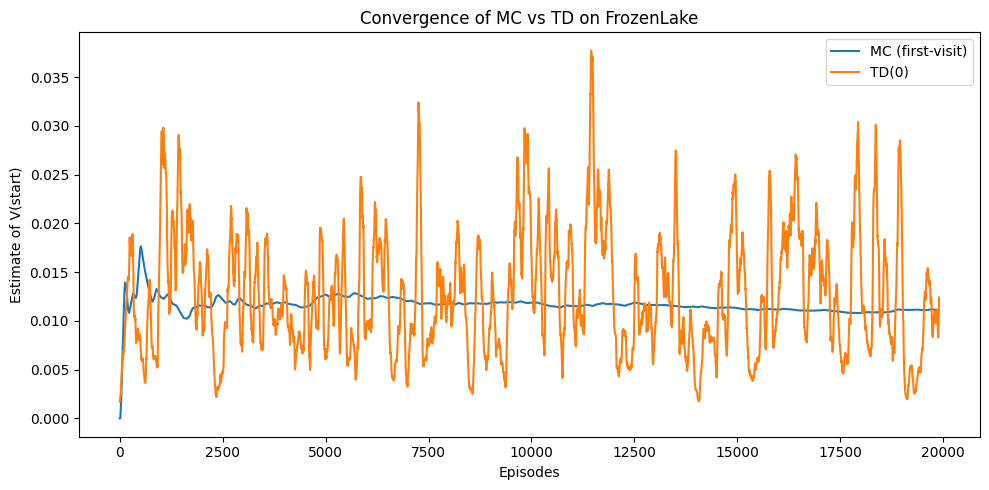

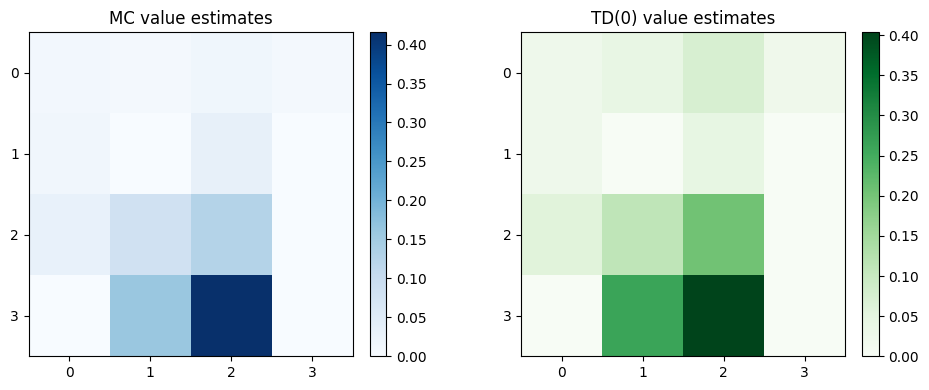

Saved MC episode 1 (return=0.00) to /Users/denissamatov/ML/RL/RL_course/code/08_mc_vs_td/videos/frozenlake/mc/mc_top01_episode_0001_return_0.00.mp4
Saved MC episode 2 (return=0.00) to /Users/denissamatov/ML/RL/RL_course/code/08_mc_vs_td/videos/frozenlake/mc/mc_top02_episode_0002_return_0.00.mp4
Saved MC episode 3 (return=0.00) to /Users/denissamatov/ML/RL/RL_course/code/08_mc_vs_td/videos/frozenlake/mc/mc_top03_episode_0003_return_0.00.mp4
Saved TD(0) episode 3 (return=1.00) to /Users/denissamatov/ML/RL/RL_course/code/08_mc_vs_td/videos/frozenlake/td/td(0)_top01_episode_0003_return_1.00.mp4
Saved TD(0) episode 1 (return=0.00) to /Users/denissamatov/ML/RL/RL_course/code/08_mc_vs_td/videos/frozenlake/td/td(0)_top02_episode_0001_return_0.00.mp4
Saved TD(0) episode 2 (return=0.00) to /Users/denissamatov/ML/RL/RL_course/code/08_mc_vs_td/videos/frozenlake/td/td(0)_top03_episode_0002_return_0.00.mp4


In [ ]:
# Сравнение MC и TD при обучении на FrozenLake
run_comparison(episodes=20000, gamma=0.99, alpha=0.1, max_steps=200, slippery=False, seed=42)

## Вывод

Эксперимент подтвердил классические различия между методами **Monte Carlo (MC)** и **Temporal Difference (TD)** при оценке функции ценности $V(s)$ на среде `FrozenLake-v1`.

- **MC (first-visit)** обновляет оценки только после завершения эпизодов.  
  Это обеспечивает низкую дисперсию, но более медленную сходимость — оценки изменяются плавно и стабилизируются после нескольких тысяч эпизодов.

- **TD(0)** выполняет обновления пошагово, используя бутстрэппинг ($r + \gamma V(s')$).  
  Метод сходится быстрее, но с большей вариативностью значений — наблюдается характерное «дрожание» вокруг истинного ожидания.

На итоговых картах ценностей оба метода демонстрируют корректное распределение:  
ценности растут по направлению к целевой клетке (внизу справа), отражая вероятность достижения цели из разных состояний.

Таким образом:
- Оба алгоритма реализованы и работают корректно.  
- TD(0) быстрее распространяет информацию о наградах, но менее стабилен.  
- MC даёт более устойчивую оценку при большом числе эпизодов.  

Это наглядно иллюстрирует фундаментальное различие между **обучением с полными возвратами (MC)** и **обучением с частичным бутстрэппингом (TD)**.
